In [9]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from scipy import linalg as LA
import random
import numpy.matlib
import kwant
import tinyarray
import multiprocessing as mp
import os
from tqdm import tqdm
import helpers as hp
from pathlib import Path
from config import PathConfigs
import scipy.sparse.linalg as sla
import multiprocessing as mp
from functools import partial
from scipy.signal import find_peaks
from scipy.spatial import KDTree

from IPython.display import display, HTML
from main_parallel import worker_pdi_step, worker_simulation_step
display(HTML('<script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>'))



#pauli matrices
sigma_0 = tinyarray.array([[1, 0], [0, 1]])
sigma_x = tinyarray.array([[0, 1], [1, 0]])
sigma_y = tinyarray.array([[0, -1j], [1j, 0]])
sigma_z = tinyarray.array([[1, 0], [0, -1]])

In [10]:
np.arange(5).tolist()

[0, 1, 2, 3, 4]

In [11]:

save_plots = True

dirname = Path(PathConfigs.DATA/"Protocol_V2/disorder_realization_109_results")
#dirname = Path(PathConfigs.DATA/"one_disorder/disorder_realization_00")
#dirname = Path(PathConfigs.DATA/"Sep_Var/sep_65_results")

plot_dir = Path(dirname, "Plots")
os.makedirs(plot_dir, exist_ok=True)


In [12]:

#dir = Path(PathConfigs.DATA/"non_interacting_test")
#dir = Path(PathConfigs.DATA/"nomushift"/"vdis2_b_strdis")
os.makedirs(Path(dirname), exist_ok=True)

#params = np.load(Path(dir/"all_params.npz"))
params = np.load(Path(dirname/"all_params.npz"), allow_pickle=True)
mu_n = float(params['mu_n'])
t = float(params['t'])
mu_leads =float(params['mu_leads'])
Delta0 = float(params['Delta0'])
gamma = float(params['gamma'])
alpha = float(params['alpha'])
Ln = int(params['Ln']) # normal metal length
Lb = int(params['Lb']) #barrier length
Ls = int(params['Ls']) #super conductor length
barrier_l = float(params['barrier0'])
V0 = float(params['V0'])
points = 100#int(params['Upoints'])

totlen = Ln + Lb +Ls 

paramd = {name:params[name] for name in params.files}
del paramd['Vdisx']
del paramd['energies']
del paramd['barrier_arr']
del paramd['mu_var']


pdicalc = hp.PDICalculator(t, alpha, gamma, Ls, params['Vdisx'], V0)

In [13]:

barrier_left_conductance_left_arr = hp.np_load_wrapped("barrier_left_conductance_left_arr", dirname)
barrier_right_conductance_right_arr = hp.np_load_wrapped("barrier_right_conductance_right_arr", dirname)
barrier_left_conductance_right_arr = hp.np_load_wrapped("barrier_left_conductance_right_arr", dirname)
barrier_right_conductance_left_arr = hp.np_load_wrapped("barrier_right_conductance_left_arr", dirname)
dIdVs_left_arr = hp.np_load_wrapped("dIdVs_left_arr", dirname)
dIdVs_right_arr = hp.np_load_wrapped("dIdVs_right_arr", dirname)
energies = hp.np_load_wrapped("energies", dirname)
pdi_arr = hp.np_load_wrapped("pdi_data", dirname)
#Conductance_matrix = hp.np_load_wrapped("Conductance_matrix_zero_energy", dirname)
#gamma_sq_arr = hp.np_load_wrapped("gamma_sq_arr", dirname)
#mp_arr = hp.np_load_wrapped("mp_arr", dirname)
rG_corr = hp.np_load_wrapped("rG_corr", dirname)
params_list = np.load(Path(dirname, 'params_list.npy'))
#spectrum_arr = hp.np_load_wrapped("spectrum_arr", dirname)
Vdisx = hp.np_load_wrapped("Vdisx", dirname)
barrier_arr = hp.np_load_wrapped("barrier_arr", dirname)
peaks_left = hp.np_load_wrapped("peaks_left", dirname)
peaks_right = hp.np_load_wrapped("peaks_right", dirname)
site_localizations = 1 - (hp.np_load_wrapped("site_localizations", dirname)/300)
weight_localizations = hp.np_load_wrapped("weight_localization_arr", dirname)
overlaps = hp.np_load_wrapped("OverlapIntegral", dirname)
mzm_seps = hp.np_load_wrapped("mzm_separation_arr", dirname)

Vdisx = params['Vdisx']  * V0


#ldos = hp.np_load_wrapped("LDOS", dirname)

#return [mu_pm * V_c, vz_raw, pdi_val]
#new_pdi_dat = np.asarray([[pdr[0]/V_c, pdr[1]*V_c, pdr[2]] for pdr in pdi_arr])




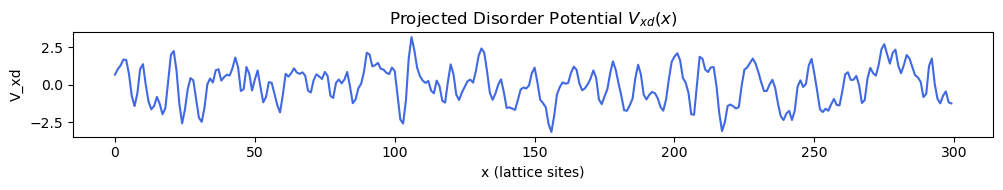

ΔVd = 0.0000
sqrt[<Vxd²>] = 1.2000


<Figure size 640x480 with 0 Axes>

In [14]:
Nx = len(Vdisx)
plt.figure(figsize=(10, 2))
plt.plot(np.arange(Nx), Vdisx, color='royalblue')
plt.xlabel("x (lattice sites)")
plt.ylabel("V_xd")
plt.title("Projected Disorder Potential $V_{xd}(x)$")
plt.gca().set_aspect('auto')
plt.tight_layout()
plt.show()

# mean and variance
DeltaVd = np.mean(Vdisx)
VarVd = np.mean(Vdisx**2)
print(f"ΔVd = {DeltaVd:.4f}")
print(f"sqrt[<Vxd²>] = {np.sqrt(VarVd):.4f}")
plt.savefig(Path(dirname,'Plots',"disorder.png"))

In [15]:
import numpy as np
import plotly.graph_objects as go

# Assuming pdi_arr and filter_pdi are already defined in your environment
mu = pdi_arr[:, 0]    # y-axis in the plot
V_z = pdi_arr[:, 1]   # x-axis in the plot
I = hp.filter_pdi(pdi_arr[:, 2]) # * weight_localizations * mzm_seps # z-axis (color)
#I = pdi_arr[:, 2]  # z-axis (color)

# Create the interactive Plotly heatmap/contour
fig = go.Figure(data=go.Contour(
    x=V_z,
    y=mu,
    z=I,
    colorscale='tempo_r',  # Matches Matplotlib's 'viridis'
    ncontours=100,         # Matches the levels=100 argument
    line_width=0,  
    showscale=True,
    contours=dict(
        coloring='heatmap',
        showlines=False
    ),
    colorbar=dict(
        title=''
    )
))

# Label axes and title
# Plotly naturally renders LaTeX enclosed in $ symbols
fig.update_layout(
    title='Winding Number',
    xaxis_title=r'$V_z$ meV',
    yaxis_title=r'$\mu$ meV',
    xaxis_range=[0.0, 1.2],  # <-- SET YOUR X-AXIS LIMITS HERE
    yaxis_range=[0, 4],
    width=400,
    height=700
)

fig.show()

fig.write_image(Path(plot_dir, 'Winding_Number.png'))


In [16]:
def has_peaks(one_array, return_float = False):
    pks = find_peaks(one_array)[0]
    lnpks = len(pks)
    if return_float:
        if lnpks == 0:
            return 0.0
        return float(pks[0])
    else:
        return lnpks != 0

def has_negative_peaks(one_array):
    return np.asarray(len(find_peaks(-one_array)[0]) != 0)


def has_max_symm(one_arr):
    #checks that maximum conductance is at the symmetric barrier
    ismax_1 = all(one_arr <= one_arr[0])
    return ismax_1 
    

def get_cpeak_dists(cond_arr1, cond_arr2):
    pks1 = np.asarray([has_peaks(cond_arr1[i,:], return_float=True) for i in range(cond_arr2.shape[0])])
    pks2 = np.asarray([has_peaks(cond_arr2[i,:], return_float=True) for i in range(cond_arr2.shape[0])])
    ret = np.asarray([[pks1[i], pks2[i]] for i in range(cond_arr2.shape[0])])
    return ret


def has_peaks_in_window(peak_data, window):
    #checks dIdV if there is a peak in a given energy window
    #[has_peaks, has_both, pos_eng, pos_eng_height, neg_eng, neg_eng_height]
    
    pos_peak_eng = peak_data[2]
    neg_peak_eng = peak_data[4]
    
    return (np.abs(pos_peak_eng) <= window) and (np.abs(neg_peak_eng) <= window)

    
def has_symmetric_peaks(peak_data):
    #checks dIdV if there is a peak in a given energy window
    #[has_peaks, has_both, pos_eng, pos_eng_height, neg_eng, neg_eng_height]
    
    pos_peak_eng = peak_data[2]
    neg_peak_eng = peak_data[4]
    
    return np.isclose(np.abs(pos_peak_eng) - np.abs(neg_peak_eng), 0)



def get_inside_points_function(pdi_arr):
    #generates function with precomputed point tree
    mu = pdi_arr[:, 0]   
    V_z = pdi_arr[:, 1] 
    points = np.column_stack((V_z, mu))
    tree = KDTree(points)

    def get_inside_points(center, r):
        #center is a tuple (Vz, mu)
        inside = tree.query_ball_point(center, r)
        
        return inside

    return get_inside_points



def check_peak_window(peaks_data_left, peaks_data_right, window):
    #checks that positive and negative peaks are in the energy window
    condition  = lambda i: has_peaks_in_window(peaks_data_left[i,:], window) \
                            and has_peaks_in_window(peaks_data_right[i,:], window)
                            
    return np.asarray([condition(i) for i in range(peaks_data_right.shape[0])])




def check_peak_symmetry(peaks_data_left, peaks_data_right):
    
    condition  = lambda i: has_symmetric_peaks(peaks_data_left[i,:]) \
                            and has_symmetric_peaks(peaks_data_right[i,:])
                            
    return np.asarray([condition(i) for i in range(peaks_data_right.shape[0])])
                            
    

def check_arr_monotonic(cond_arr1, cond_arr2):
    is_monotonic_arr = np.asarray([(np.all(np.diff(cond_arr1[i,:])<=0) &
                        np.all(np.diff(cond_arr2[i,:])<=0)).astype(int) for i in range(cond_arr2.shape[0])])
    
    return is_monotonic_arr
    
    

def check_max_at_symm(cond_arr1, cond_arr2):
    #checks that both have maximum conductance at symmetric barrier
    condition = lambda i: has_max_symm(cond_arr1[i,:]) and has_max_symm(cond_arr1[i,:])
    ret = np.asarray([condition(i) for i in range(cond_arr2.shape[0])]).astype(int)
    return ret
    


def check_resonance_peak(cond_arr1, cond_arr2):
    #return np.asarray([has_peaks(cond_arr2[i,:]) for i in range(cond_arr2.shape[0])]).astype(int)
    return np.asarray([has_peaks(cond_arr1[i,:]) and  has_peaks(cond_arr2[i,:]) for i in range(cond_arr2.shape[0])]).astype(int)



def check_negative_peaks(cond_arr1, cond_arr2):
    #return np.asarray([has_negative_peaks(cond_arr1[i,:]) or has_negative_peaks(cond_arr2[i,:]) for i in range(cond_arr2.shape[0])]).astype(int)
    return np.asarray([has_negative_peaks(cond_arr1[i,:]) or has_negative_peaks(cond_arr2[i,:]) for i in range(cond_arr2.shape[0])]).astype(int)



def check_correlation(cond_arr1, cond_arr2, corr_thresh):
    
    corrs = np.asarray([hp.calc_correlation(cond_arr1[i,:], cond_arr2[i,:]) for i in range(cond_arr2.shape[0])])
    corrs = np.asarray([1.0 if corr > 1 else corr for corr in corrs])
    corrs = np.asarray([0.0 if corr < 0.0 else corr for corr in corrs])
    corrs = np.asarray([0.0 if corr < corr_thresh else corr for corr in corrs])
    corrs = np.asarray([1.0 if corr > corr_thresh else corr for corr in corrs])
    
    return corrs
    



def check_island_stability(corrs, peaks_window, pdi_arr, radius=0.05, frac=1.0):
    #checks that all points within an island still have correlated conductance
    get_inside_pts = get_inside_points_function(pdi_arr)
    
    mu = pdi_arr[:, 0]
    V_z = pdi_arr[:, 1]
    points = np.column_stack((V_z, mu))
    
    stable_arr = np.zeros_like(corrs)
    
    arr_check = corrs
    if peaks_window is not None:
        arr_check *= peaks_window
    
    for i in range(len(corrs)):
        if arr_check[i] > 0:
            neighbors = get_inside_pts(points[i], radius)
            if len(neighbors) > 0:
                correlated_neighbors = sum(1 for n in neighbors if arr_check[n] > 0)
                if (correlated_neighbors / len(neighbors)) >= frac:
                    stable_arr[i] = 1.0
            else:
                stable_arr[i] = 1.0
                
    return stable_arr



def compute_probabilities(protocol_map, winding_map):
    A_bool = winding_map == 1.0
    B_bool = protocol_map == 1.0
    
    #conditional that phase is trivial given potitive protocol P(Trivial | Positive Protocol)
    p_not_a_given_b = np.sum(~A_bool & B_bool) / np.sum(B_bool) if np.sum(B_bool) > 0 else np.nan
    
    #conditional that protocol is negative given topological P(Negative Protocol | Topological)
    p_not_b_given_a = np.sum(A_bool & ~B_bool) / np.sum(A_bool) if np.sum(A_bool) > 0 else np.nan
    
    return p_not_a_given_b, p_not_b_given_a



In [22]:
def calc_protocol(cond_arr1, cond_arr2, peaks_data_left, peaks_data_right, **kwargs):
    
    prot_dat = np.ones_like(cond_arr1[:,0])
    
    #=== correlation filtering =======#
    if kwargs['check_correlation']:
        corrs = check_correlation(cond_arr1, cond_arr2, kwargs["corr_thresh"])
        prot_dat *= corrs
    
    #=== peak filtering in conductances =======#
    if kwargs['check_resonance_peak']:
        has_peak_arr = check_resonance_peak(cond_arr1, cond_arr2) 
        prot_dat *= (1 - has_peak_arr) #inverse condition
        
    if kwargs['check_negative_peaks']:
        has_neg_peaks = check_negative_peaks(cond_arr1, cond_arr2) 
        prot_dat *= (1 - has_neg_peaks)
        
    if kwargs['check_monotonic']:
        is_monotonic = check_arr_monotonic(cond_arr1, cond_arr2)
        prot_dat *= is_monotonic
        
    #==== Peak window and symmetry filtering in dI/dV==========#
    
    if kwargs['check_peak_symmetry']:
        are_symmetric = check_peak_symmetry(peaks_data_left, peaks_data_left)
        prot_dat *= are_symmetric
        
    if kwargs['check_peak_window']:
        peaks_in_window = check_peak_window(peaks_data_left, peaks_data_right, kwargs["window"])
        prot_dat *= peaks_in_window
        
    #============ Check island stability ============#
        
    if kwargs['check_island_stability']:
        
        in_stable_island = check_island_stability(corrs, peaks_in_window, pdi_arr, 
                                               radius=kwargs['stability_radus'], frac=kwargs['stability_frac'])
        
        prot_dat *= in_stable_island
        
    return prot_dat
        

In [23]:
params = {
    "check_correlation"      : True,
    "check_resonance_peak"   : False,
    "check_negative_peaks"   : False,
    "check_monotonic"        : False,
    "check_peak_symmetry"    : False, 
    "check_peak_window"      : True,
    "check_island_stability" : True,
    
    "corr_thresh"     : 0.9,
    "window"          : 0.045,
    "stability_radus" : 0.05,
    "stability_frac"  : 1.0
    
    
}


In [24]:
brcl = barrier_right_conductance_left_arr
brcr = barrier_right_conductance_right_arr


mzm_seps = np.asarray([1 if s >= 0.2 else 0.0 for s in mzm_seps])
weight_localizations = np.asarray([1 if s >= 0.8 else 0.0 for s in weight_localizations])

I = hp.filter_pdi(pdi_arr[:, 2]) 

corrs = np.asarray([hp.calc_correlation(brcl[i,:], brcr[i,:]) for i in range(brcl.shape[0])])

cdists = get_cpeak_dists(brcl, brcr)

prot_dat = calc_protocol(brcl, brcr, peaks_left, peaks_right, **params)
zplot = I - prot_dat  #pks * (1 - check_correlation(brcl, brcr, corr_thresh=0.9))

In [25]:
maxd = 1000
mu = params_list[:, 1]   # y-axis in the plot
V_z = params_list[:, 2]  # x-axis in the plot
#zplot =  corrs           # z-axis (color)
#(corrs.astype(bool) * ~I.astype(bool)).astype(int)           # z-axis (color)

# Create the interactive Plotly heatmap/contour
fig = go.Figure(data=go.Contour(
    x=V_z,
    y=mu,
    z=zplot,
    colorscale='thermal',    # Matches Matplotlib's 'magma'
    ncontours=100,         # Smooth continuous gradient
    line_width=0,          # Removes contour lines
    contours=dict(
        coloring='heatmap',
        showlines=False
    ),
    colorbar=dict(
        title=''
    )
))
#fig.update_xaxes(title=dict(text=r'\mu'))

# Label axes and title
fig.update_layout(
    title='Has Resonance Peak in Conductance on Both Sides',
    xaxis_range=[0.0, 1.2],  # <-- SET YOUR X-AXIS LIMITS HERE
    yaxis_range=[0, 4.5],
    width=400,
    height=700,
    xaxis_title=r'$V_z$',
    yaxis_title=r'$\mu$',
)
fig.show()

In [26]:
res= compute_probabilities(prot_dat, I)
print(f"P(Trivial | Positive Protocol):  {res[0]} |  P(Negative Protocol | Topological):   {res[1]}")

#P(Trivial | Positive Protocol):  0.25882352941176473 |  P(Negative Protocol | Topological):   0.33236994219653176
#P(Trivial | Positive Protocol):  0.2045009784735812 |  P(Negative Protocol | Topological):   0.47784200385356457

P(Trivial | Positive Protocol):  0.3551912568306011 |  P(Negative Protocol | Topological):   0.9549618320610687
